In [1]:
import os
import sys
import torch
import numpy as np
from scipy import stats

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))

from models.source.pnncritic import HybridActorNoTimeNoPrevAction 
from environment.config import markov_config
from stable_baselines3 import SAC

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS is available. Using Apple Silicon GPU.")
elif torch.backends.mps.is_built():
    print("MPS is built, but not available (likely an older macOS).")
    device = torch.device("cpu")
else:
    print("MPS not available. Using CPU.")
    device = torch.device("cpu")

MPS is built, but not available (likely an older macOS).


In [2]:
# PNNcritic2 copy 3

checkpoint = torch.load("saved_models/pnncritic.pth", map_location=device)

# Reconstruct the Actor using the saved dimensions
actor = HybridActorNoTimeNoPrevAction(
    state_dim=checkpoint["state_dim"],
    action_dim=checkpoint["action_dim"],
    hidden_dim=checkpoint["hidden_dim"]
).to(device)

# Load the weights into the Actor
actor.load_state_dict(checkpoint["actor_state_dict"])

# Set to evaluation mode (turns off gradients and exploration)
actor.eval()




HybridActorNoTimeNoPrevAction(
  (trunk): Sequential(
    (0): Linear(in_features=29, out_features=64, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ELU(alpha=1.0)
  )
  (action_head): Linear(in_features=64, out_features=6, bias=True)
)

In [3]:
sac_model = SAC.load("saved_models/sacdp.zip")

--- Evaluation Results (Seed: 125) ---
SAC Terminal NAV: 718.97 € | Utility: -0.49
PNN Terminal NAV: 725.24 € | Utility: -0.48



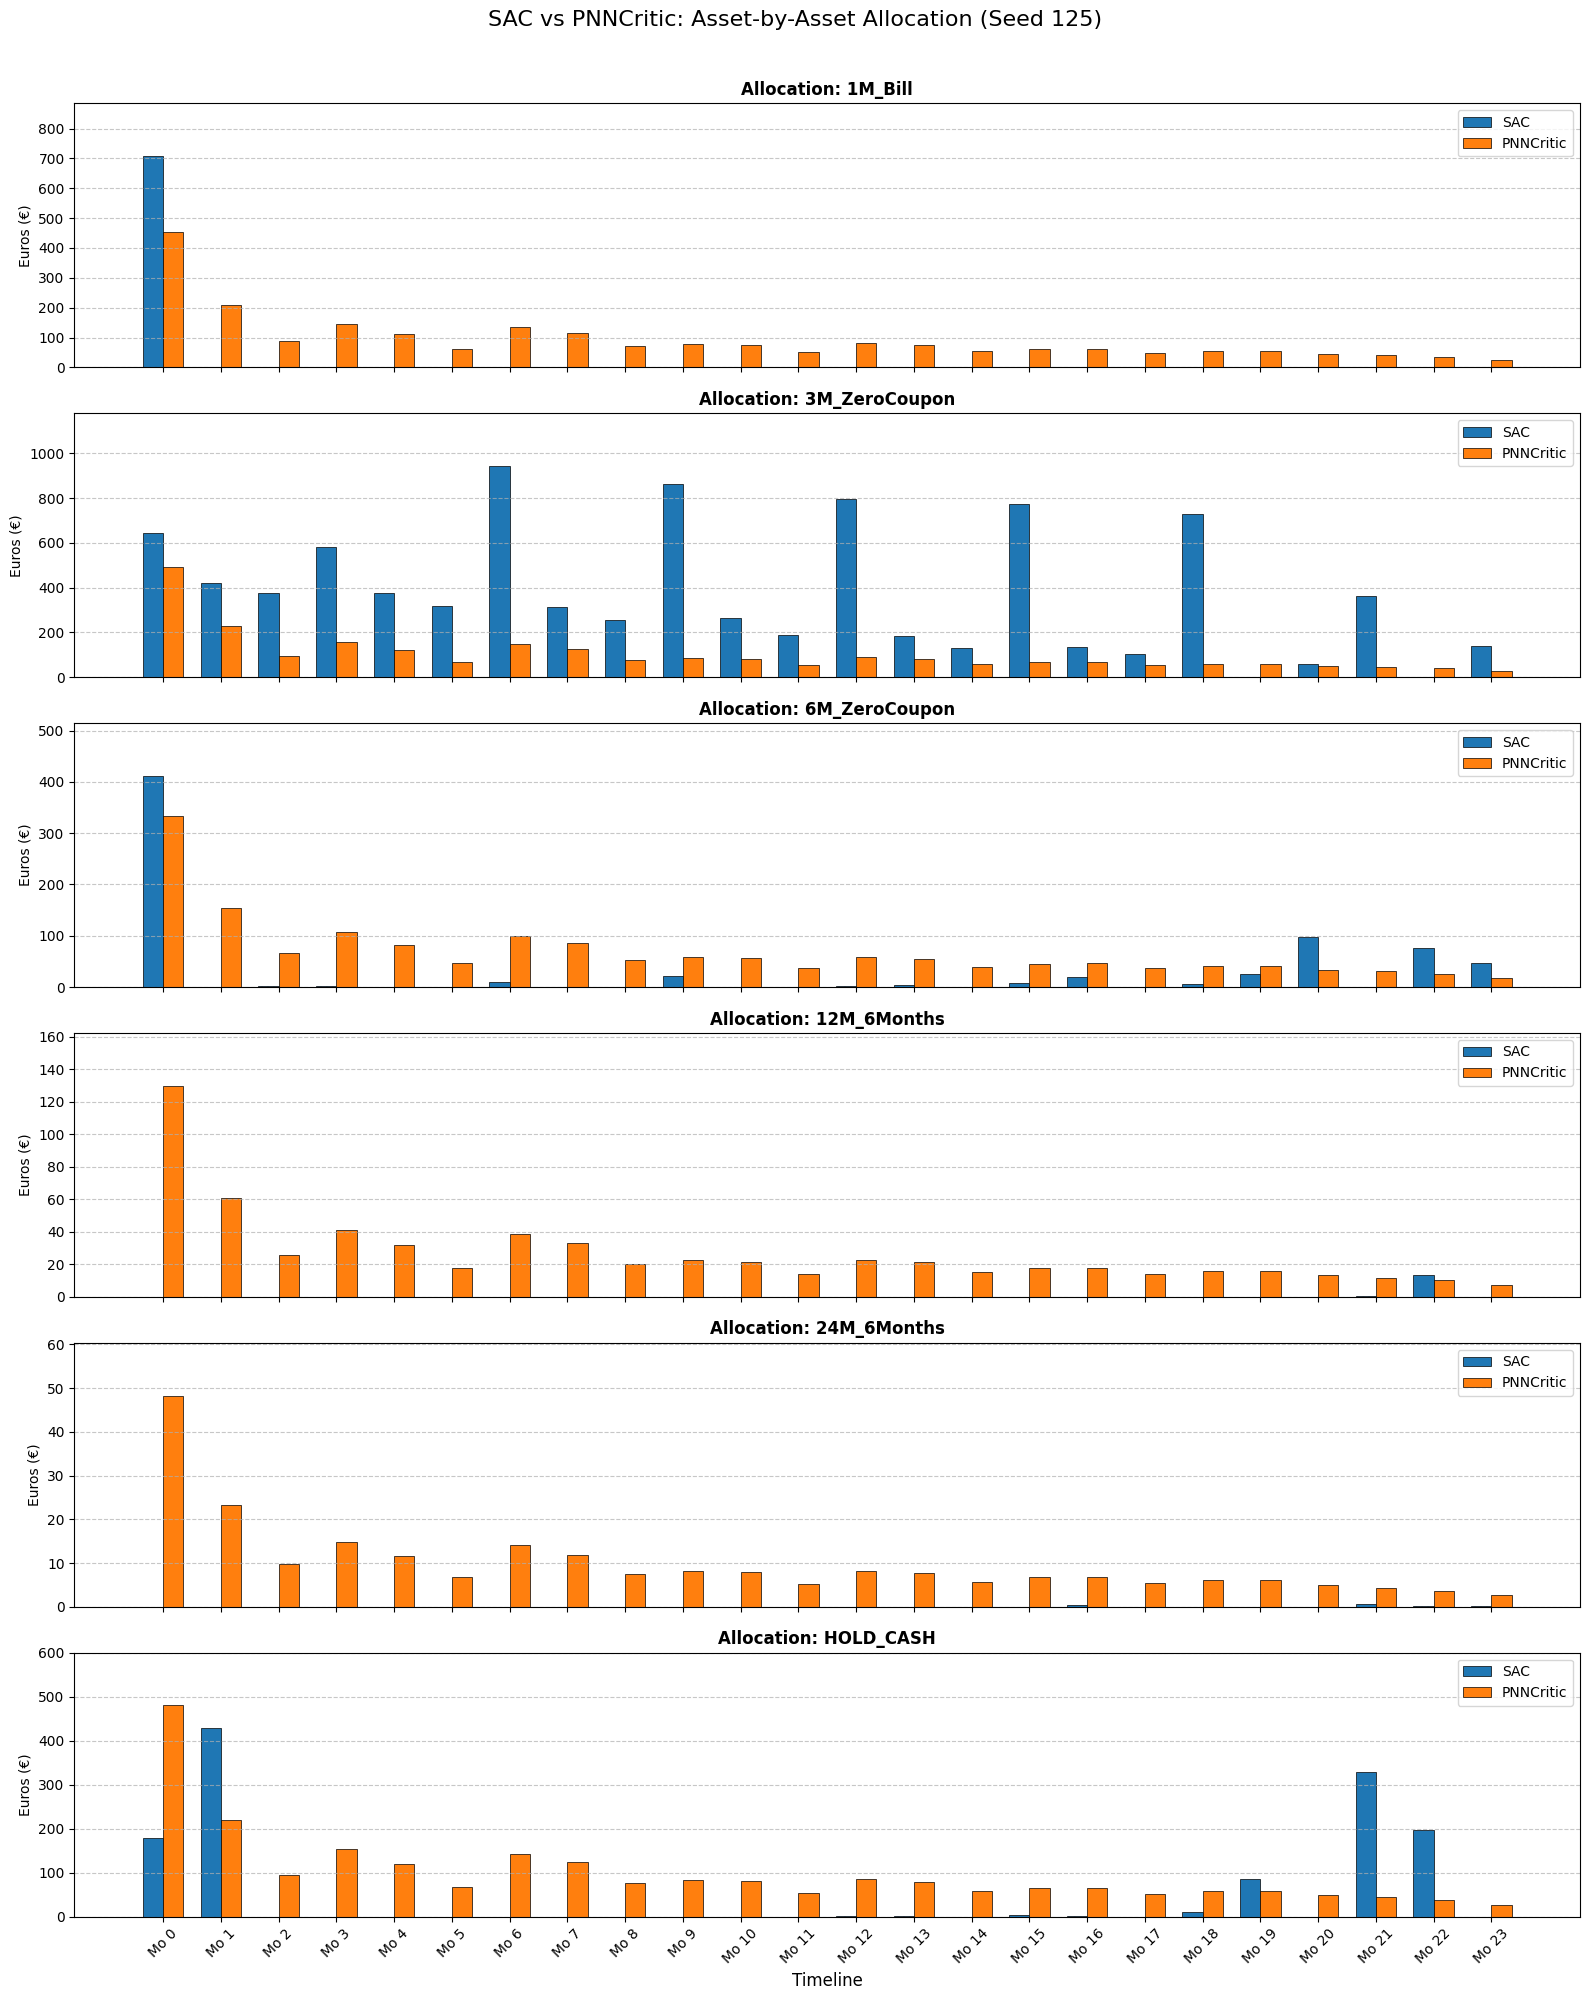

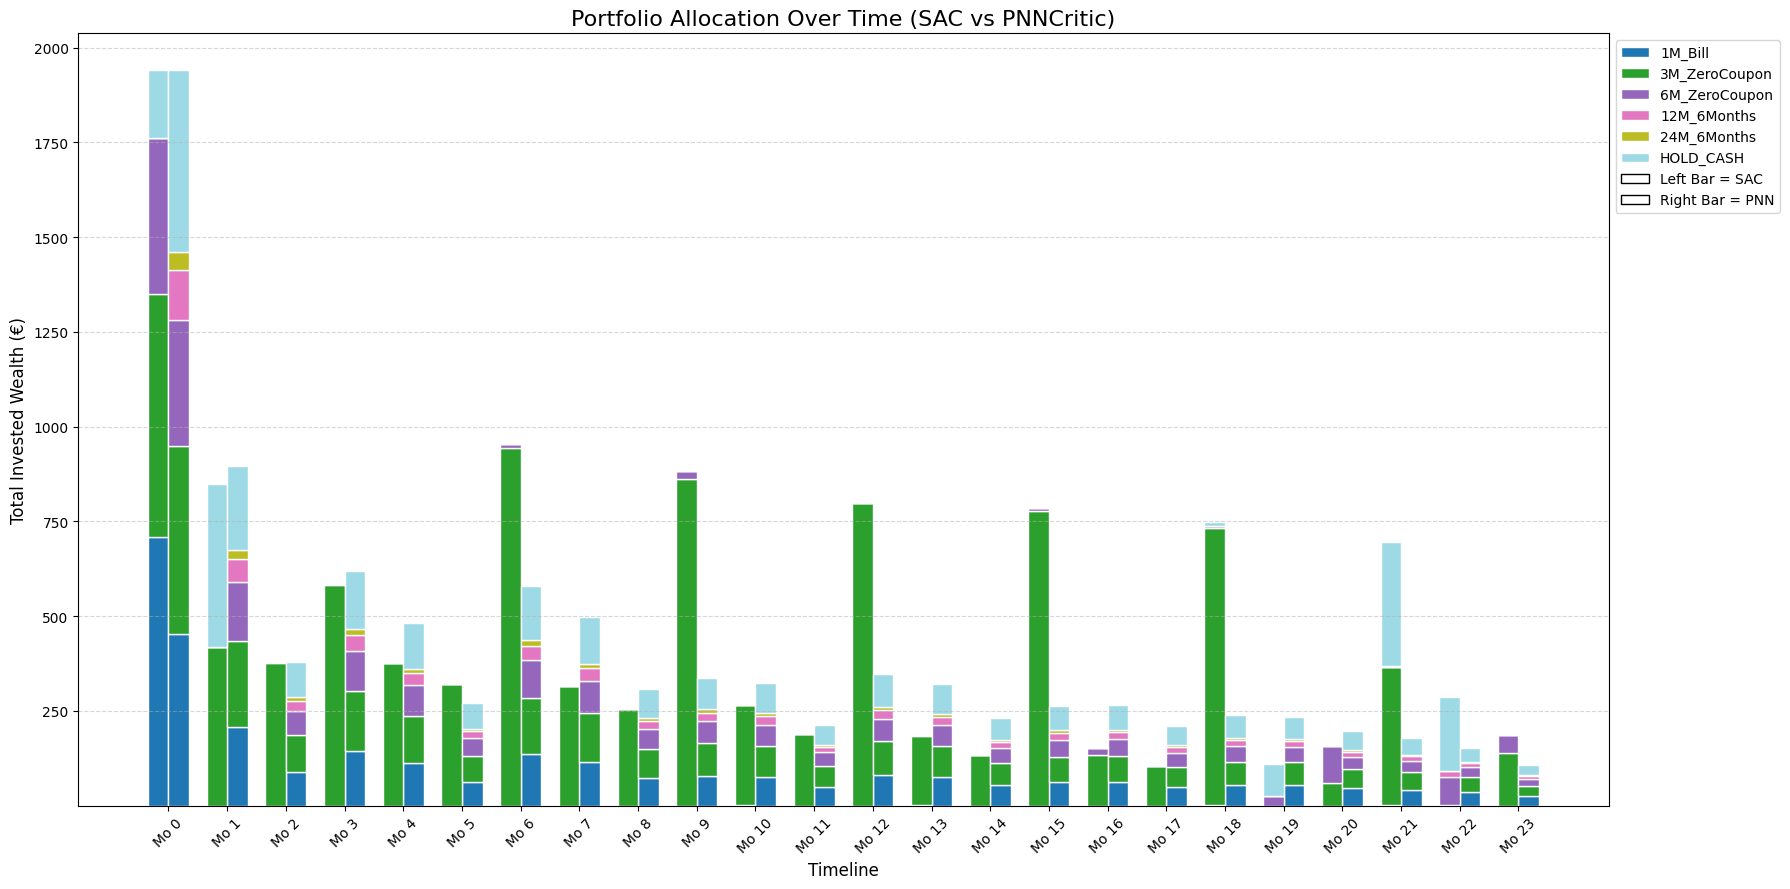

In [4]:
from models.compare import compare_allocations

compare_allocations(actor, sac_model, markov_config, K=5, seed=125)

In [5]:
def collect_terminal_navs(evaluator, model, markov_config, K, seeds,
                          nav_index=2, log_every=5000):
    navs = np.empty(len(seeds), dtype=np.float64)
    for i, s in enumerate(seeds):
        out = evaluator(model, markov_config, K, seed=int(s), verbose=False)
        navs[i] = float(out[nav_index])          # terminal_nav
        if log_every and (i + 1) % log_every == 0:
            print(f"  ... {i + 1:,}/{len(seeds):,}  (NAV media corrente: {navs[:i+1].mean():.2f})")
    return navs

In [6]:
from models.source.sac import evaluate_sac_agent
from models.source.pnncritic import evaluate_pnncritic_agent
N_SEEDS = 100_000
seeds = np.arange(N_SEEDS) 
print("Collecting NAV (SAC)...")
nav_sac = collect_terminal_navs(evaluate_sac_agent, sac_model, markov_config, 5, seeds)
 
print("Collecting NAV (our proposal)...")
nav_ours = collect_terminal_navs(evaluate_pnncritic_agent, actor, markov_config, 5, seeds)
 

  ... 5,000/100,000  (NAV media corrente: 690.87)
  ... 10,000/100,000  (NAV media corrente: 690.50)
  ... 15,000/100,000  (NAV media corrente: 690.62)
  ... 20,000/100,000  (NAV media corrente: 690.71)
  ... 25,000/100,000  (NAV media corrente: 690.92)
  ... 30,000/100,000  (NAV media corrente: 690.66)
  ... 35,000/100,000  (NAV media corrente: 690.54)
  ... 40,000/100,000  (NAV media corrente: 690.67)
  ... 45,000/100,000  (NAV media corrente: 690.97)
  ... 50,000/100,000  (NAV media corrente: 690.81)
  ... 55,000/100,000  (NAV media corrente: 690.83)
  ... 60,000/100,000  (NAV media corrente: 690.69)
  ... 65,000/100,000  (NAV media corrente: 690.64)
  ... 70,000/100,000  (NAV media corrente: 690.64)
  ... 75,000/100,000  (NAV media corrente: 690.76)
  ... 80,000/100,000  (NAV media corrente: 690.80)
  ... 85,000/100,000  (NAV media corrente: 690.71)
  ... 90,000/100,000  (NAV media corrente: 690.70)
  ... 95,000/100,000  (NAV media corrente: 690.73)
  ... 100,000/100,000  (NAV medi

In [7]:
print("Collecting NAV (our proposal)...")
nav_ours = collect_terminal_navs(evaluate_pnncritic_agent, actor, markov_config, 5, seeds)

  ... 5,000/100,000  (NAV media corrente: 698.74)
  ... 10,000/100,000  (NAV media corrente: 698.37)
  ... 15,000/100,000  (NAV media corrente: 698.31)
  ... 20,000/100,000  (NAV media corrente: 698.38)
  ... 25,000/100,000  (NAV media corrente: 698.51)
  ... 30,000/100,000  (NAV media corrente: 698.26)
  ... 35,000/100,000  (NAV media corrente: 698.18)
  ... 40,000/100,000  (NAV media corrente: 698.29)
  ... 45,000/100,000  (NAV media corrente: 698.58)
  ... 50,000/100,000  (NAV media corrente: 698.43)
  ... 55,000/100,000  (NAV media corrente: 698.47)
  ... 60,000/100,000  (NAV media corrente: 698.35)
  ... 65,000/100,000  (NAV media corrente: 698.29)
  ... 70,000/100,000  (NAV media corrente: 698.31)
  ... 75,000/100,000  (NAV media corrente: 698.44)
  ... 80,000/100,000  (NAV media corrente: 698.49)
  ... 85,000/100,000  (NAV media corrente: 698.41)
  ... 90,000/100,000  (NAV media corrente: 698.36)
  ... 95,000/100,000  (NAV media corrente: 698.38)
  ... 100,000/100,000  (NAV medi

In [ ]:
np.save("test-diff/nav_sac.npy", nav_sac)
np.save("test-diff/nav_ours.npy", nav_ours)
 
print(f"  SAC  : mean = {nav_sac.mean():.2f},  bankrupt = {(nav_sac < 0).mean()*100:.3f}%")
print(f"  Ours : mean = {nav_ours.mean():.2f}, bankrupt = {(nav_ours < 0).mean()*100:.3f}%")
 
corr = np.corrcoef(nav_ours, nav_sac)[0, 1]
print(f"  Correlation NAV(ours, SAC) = {corr:.4f}")
 

  SAC  : mean = 690.76,  bankrupt = 0.000%
  Ours : mean = 698.42, bankrupt = 0.052%
  Correlation NAV(ours, SAC) = 0.9890


In [9]:
nav_ours = np.load("nav_ours.npy")
nav_sac  = np.load("nav_sac.npy")

assert nav_ours.shape == nav_sac.shape, "Arrays must have the same length and be aligned by seed"
N = len(nav_ours)

ALPHA = 0.05            # level for 95% CI
ALPHA_TAIL = 0.05       # tail for VaR/CVaR (5%)
N_BOOT = 10_000         # bootstrap repetitions
RNG = np.random.default_rng(0)


def var_lower(x, q=ALPHA_TAIL):
    return np.percentile(x, 100 * q)

def cvar_lower(x, q=ALPHA_TAIL):
    thr = np.percentile(x, 100 * q)
    return x[x <= thr].mean()

# PAIRED BOOTSTRAP
def paired_bootstrap_ci(stat_fn, a, b, n_boot=N_BOOT, alpha=ALPHA, rng=RNG):
    """Bootstrap CI (percentile) on the difference stat_fn(a) - stat_fn(b)."""
    n = len(a)
    diffs = np.empty(n_boot)
    for k in range(n_boot):
        idx = rng.integers(0, n, n)          # same indices for a and b -> paired
        diffs[k] = stat_fn(a[idx]) - stat_fn(b[idx])
    lo, hi = np.percentile(diffs, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    point = stat_fn(a) - stat_fn(b)
    return point, lo, hi


d = nav_ours - nav_sac
mean_diff = d.mean()
sem_diff = d.std(ddof=1) / np.sqrt(N)
ci_lo = mean_diff - stats.norm.ppf(1 - ALPHA / 2) * sem_diff
ci_hi = mean_diff + stats.norm.ppf(1 - ALPHA / 2) * sem_diff

# Paired t-test
t_stat, p_t = stats.ttest_rel(nav_ours, nav_sac)

# Wilcoxon signed-rank
w_stat, p_w = stats.wilcoxon(nav_ours, nav_sac)

# Effect size: Cohen's d
cohens_d = mean_diff / d.std(ddof=1)

# Correlation between the two NAVs (shows why pairing matters)
corr = np.corrcoef(nav_ours, nav_sac)[0, 1]

print("=" * 70)
print(f"N = {N:,} seed  |  correlation NAV(ours, SAC) = {corr:.4f}")
print("  (high correlation -> the paired design greatly reduces variance)")
print("=" * 70)
print("\n--- NAV MEAN (paired difference: ours - SAC) ---")
print(f"  Mean ours          : {nav_ours.mean():.2f}  (SEM {nav_ours.std(ddof=1)/np.sqrt(N):.3f})")
print(f"  Mean SAC           : {nav_sac.mean():.2f}  (SEM {nav_sac.std(ddof=1)/np.sqrt(N):.3f})")
print(f"  Mean difference    : {mean_diff:.3f}")
print(f"  95% CI (paired)    : [{ci_lo:.3f}, {ci_hi:.3f}]")
print(f"  Paired t-test      : t = {t_stat:.2f},  p = {p_t:.2e}")
print(f"  Wilcoxon           : p = {p_w:.2e}")
print(f"  Cohen's d (paired) : {cohens_d:.4f}  (0.2=small, 0.5=medium, 0.8=large)")

# VaR AND CVaR (only bootstrap: they are quantiles, no t-test)
var_point, var_lo, var_hi = paired_bootstrap_ci(var_lower, nav_ours, nav_sac)
cvar_point, cvar_lo, cvar_hi = paired_bootstrap_ci(cvar_lower, nav_ours, nav_sac)

print("\n VaR(5%) and CVaR(5%) (difference ours - SAC, paired bootstrap)")
print(f"  VaR(5%)  ours={var_lower(nav_ours):.2f}  SAC={var_lower(nav_sac):.2f}")
print(f"    diff = {var_point:.3f},  95% CI = [{var_lo:.3f}, {var_hi:.3f}]")
print(f"  CVaR(5%) ours={cvar_lower(nav_ours):.2f}  SAC={cvar_lower(nav_sac):.2f}")
print(f"    diff = {cvar_point:.3f},  95% CI = [{cvar_lo:.3f}, {cvar_hi:.3f}]")

rel = mean_diff / nav_sac.mean() * 100
print(f"  Mean relative advantage of NAV : {rel:+.2f}% of SAC NAV")

N = 100,000 seed  |  correlation NAV(ours, SAC) = 0.9890
  (high correlation -> the paired design greatly reduces variance)

--- NAV MEAN (paired difference: ours - SAC) ---
  Mean ours          : 698.42  (SEM 0.345)
  Mean SAC           : 690.76  (SEM 0.337)
  Mean difference    : 7.653
  95% CI (paired)    : [7.552, 7.753]
  Paired t-test      : t = 149.47,  p = 0.00e+00
  Wilcoxon           : p = 0.00e+00
  Cohen's d (paired) : 0.4727  (0.2=small, 0.5=medium, 0.8=large)

 VaR(5%) and CVaR(5%) (difference ours - SAC, paired bootstrap)
  VaR(5%)  ours=522.42  SAC=514.16
    diff = 8.256,  95% CI = [8.021, 8.608]
  CVaR(5%) ours=472.18  SAC=471.19
    diff = 0.990,  95% CI = [-1.063, 2.853]
  Mean relative advantage of NAV : +1.11% of SAC NAV
